In [167]:
from Bio import SeqIO
from collections import defaultdict
import argparse

absolute_codon_frequencies = {
    'TTT': 1.32,
    'TTC': 2.18,
    'TTA': 0.45,
    'TTG': 1.61,
    'CTT': 0.9,
    'CTC': 1.38,
    'CTA': 0.82,
    'CTG': 3.82,
    'ATT': 1.66,
    'ATC': 2.29,
    'ATA': 0.95,
    'ATG': 2.36,
    'GTT': 1.1,
    'GTC': 1.39,
    'GTA': 0.64,
    'GTG': 2.78,
    'TCT': 0.7,
    'TCC': 1.96,
    'TCA': 0.78,
    'TCG': 1.66,
    'AGT': 1.15,
    'AGC': 2.04,
    'CCT': 0.69,
    'CCC': 1.81,
    'CCA': 1.35,
    'CCG': 1.58,
    'ACT': 0.95,
    'ACC': 2.13,
    'ACA': 1.1,
    'ACG': 1.44,
    'GCT': 1.44,
    'GCC': 3.36,
    'GCA': 1.28,
    'GCG': 1.4,
    'TAT': 1.08,
    'TAC': 1.84,
    'TAA': 0.08,
    'TAG': 0.07,
    'TGA': 0.05,
    'CAT': 1.08,
    'CAC': 1.62,
    'CAA': 1.56,
    'CAG': 3.61,
    'AAT': 2.1,
    'AAC': 2.62,
    'AAA': 1.7,
    'AAG': 3.95,
    'GAT': 2.76,
    'GAC': 2.46,
    'GAA': 2.11,
    'GAG': 4.25,
    'TGT': 0.54,
    'TGC': 1.32,
    'TGG': 0.99,
    'CGT': 0.88,
    'CGC': 1.8,
    'CGA': 0.84,
    'CGG': 0.82,
    'AGA': 0.51,
    'AGG': 0.63,
    'GGT': 1.33,
    'GGC': 2.67,
    'GGA': 1.8,
    'GGG': 0.47
}

relative_codon_frequencies = {
    "TTT": 0.377,
    "TTC": 0.623,
    "TTA": 0.050,
    "TTG": 0.179,
    "CTT": 0.100,
    "CTC": 0.154,
    "CTA": 0.091,
    "CTG": 0.425,
    "ATT": 0.339,
    "ATC": 0.467,
    "ATA": 0.194,
    "ATG": 1.0,
    "GTT": 0.186,
    "GTC": 0.235,
    "GTA": 0.108,
    "GTG": 0.470,
    "TCT": 0.084,
    "TCC": 0.236,
    "TCA": 0.094,
    "TCG": 0.200,
    "AGT": 0.139,
    "AGC": 0.246,
    "CCT": 0.127,
    "CCC": 0.333,
    "CCA": 0.249,
    "CCG": 0.291,
    "ACT": 0.169,
    "ACC": 0.379,
    "ACA": 0.196,
    "ACG": 0.256,
    "GCT": 0.193,
    "GCC": 0.449,
    "GCA": 0.171,
    "GCG": 0.187,
    "TAT": 0.370,
    "TAC": 0.630,
    "TAA": 0.400,
    "TAG": 0.350,
    "TGA": 0.250,
    "CAT": 0.400,
    "CAC": 0.600,
    "CAA": 0.302,
    "CAG": 0.698,
    "AAT": 0.445,
    "AAC": 0.555,
    "AAA": 0.301,
    "AAG": 0.699,
    "GAT": 0.529,
    "GAC": 0.471,
    "GAA": 0.332,
    "GAG": 0.668,
    "TGT": 0.290,
    "TGC": 0.710,
    "TGG": 1.0,
    "CGT": 0.161,
    "CGC": 0.328,
    "CGA": 0.153,
    "CGG": 0.150,
    "AGA": 0.093,
    "AGG": 0.115,
    "GGT": 0.212,
    "GGC": 0.426,
    "GGA": 0.287,
    "GGG": 0.075
}

aaToCodon = {
    'F': ['TTT', 'TTC'],
    'L': ['TTA', 'TTG', 'CTT', 'CTC', 'CTA', 'CTG'],
    'I': ['ATT', 'ATC', 'ATA'],
    'M': ['ATG'],
    'V': ['GTT', 'GTC', 'GTA', 'GTG'],
    'S': ['TCT', 'TCC', 'TCA', 'TCG', 'AGT', 'AGC'],
    'P': ['CCT', 'CCC', 'CCA', 'CCG'],
    'T': ['ACT', 'ACC', 'ACA', 'ACG'],
    'A': ['GCT', 'GCC', 'GCA', 'GCG'],
    'Y': ['TAT', 'TAC'],
    'X': ['TAA', 'TAG', 'TGA'],  # Stop codons
    'H': ['CAT', 'CAC'],
    'Q': ['CAA', 'CAG'],
    'N': ['AAT', 'AAC'],
    'K': ['AAA', 'AAG'],
    'D': ['GAT', 'GAC'],
    'E': ['GAA', 'GAG'],
    'C': ['TGT', 'TGC'],
    'W': ['TGG'],
    'R': ['CGT', 'CGC', 'CGA', 'CGG', 'AGA', 'AGG'],
    'G': ['GGT', 'GGC', 'GGA', 'GGG']
}


In [168]:
# Function to calculate codon frequencies
def calculate_codon_frequencies(sequence):
    global absolute_codon_frequencies, relative_codon_frequencies, aaToCodon
    codon_counts = defaultdict(int)
    for codon in absolute_codon_frequencies.keys():
        codon_counts[codon] = 0
    total_codons = len(sequence) // 3
    for i in range(0, len(sequence) - 2, 3):
        codon = sequence[i:i+3]
        codon_counts[codon] += 1

    # # Normalize the frequences by amino acid groups and to global drosophila ratios
    # for aa, codon_list in aaToCodon.items():
    #     total_frequency = sum(codon_counts[codon] for codon in codon_list)
    #     if total_frequency > 0:
    #         for codon in codon_list:
    #             #codon_counts[codon] /= total_frequency/absolute_codon_frequencies[codon]#relative_codon_frequencies[codon]/
    #             codon_counts[codon] = codon_counts[codon]/total_frequency -relative_codon_frequencies[codon]

    codon_frequencies = {codon: count / total_codons for codon, count in codon_counts.items()}
    return codon_frequencies

def gc_content(sequence):
    gc_count = sequence.count('G') + sequence.count('C')
    return gc_count / len(sequence) if len(sequence) != 0 else 0.0



In [169]:
# Set up argument parser
parser = argparse.ArgumentParser(description='Process genomic data files for codon frequency analysis.')
parser.add_argument("--params", default='params.yaml', type=str, help="Path to the YAML file containing parameters.",)
parser.add_argument('--CDS_fasta', type=str, default="data/3UTRs/Drosophila_melanogaster-cds.fa", help='Path to the main FASTA file')
parser.add_argument('--decay_file', type=str, default="data/parameters_estimates_extended_zygotic_tr_18022025_filtered.csv", help='Path to the decay rates CSV file')
parser.add_argument('--utr_fasta', type=str, default="output/data/utrDecayRates.fasta", help='Path to the UTR FASTA file')
parser.add_argument('--trainData', type=str, default="output/data/decay/train.fasta")
parser.add_argument('--valData', type=str, default="output/data/decay/dev.fasta")

args = parser.parse_known_args()[0]
#args.valData = None


In [170]:
import os
os.chdir('/mnt/mr01-home01/m65338lb/worktrees/rnaDecay/gena_lm_extraFeatures')

import pandas as pd
# List of FlyBase transcript IDs
ourDecay = pd.read_csv(args.decay_file)
flybase_ids = ourDecay['tr_id'].tolist()

CDSs = {}
for record in SeqIO.parse(args.CDS_fasta, "fasta"):
    description = record.description
    transcript_id = description.split(" ")[0]
    if transcript_id in flybase_ids:
        CDSs[transcript_id] = record


#%%
import os

# Match FlyBase IDs to CDSs and calculate codon frequencies
codon_frequencies_dict = {}
total = 0
missing = 0
print("Missing Transcript IDs:")
for flybase_id in flybase_ids:
    total +=1
    if flybase_id in CDSs.keys():
        sequence = str(CDSs[flybase_id].seq)
        codon_frequencies = calculate_codon_frequencies(sequence)
        codon_frequencies_dict[flybase_id] = codon_frequencies
    else:
        print(flybase_id)
        missing +=1

print(f"Total: {total}   Missing: {missing}")


Missing Transcript IDs:
FBtr0091871
Total: 655   Missing: 1


In [171]:
import pandas as pd
import numpy as np
from Bio import SeqIO

# Read in the UTR fasta file
utr5_utr3 = list(SeqIO.parse(args.utr_fasta, "fasta"))
utr5_utr3 = {r.description.split()[1]:r for r in utr5_utr3}

# Extract decay rates and sequence lengths
tr_ids = []
decay_rates = []
utr5_lengths = []
cds_lengths = []
utr3_lengths = []
utr5_gc = []
cds_gc = []
utr3_gc = []
for tr_id in codon_frequencies_dict.keys():
    if tr_id in utr5_utr3:
        tr_ids.append(tr_id)
        decay_rates.append(float(utr5_utr3[tr_id].id))
        utr5_lengths.append(len(str(utr5_utr3[tr_id].seq).split(',')[0]))
        cds_lengths.append(len(str(CDSs[tr_id].seq)))
        utr3_lengths.append(len(str(utr5_utr3[tr_id].seq).split(',')[1]))
        utr5_gc.append(gc_content(str(utr5_utr3[tr_id].seq).split(',')[0]))
        cds_gc.append(gc_content(str(CDSs[tr_id].seq)))
        utr3_gc.append(gc_content(str(utr5_utr3[tr_id].seq).split(',')[1]))

# Create a DataFrame for easier manipulation
decay_data = pd.DataFrame({
    "Decay Rate": decay_rates,
    "5' UTR Length": utr5_lengths,
    "CDS Length": cds_lengths,
    "3' UTR Length": utr3_lengths,
    "5' UTR GC Content": utr5_gc,
    "CDS GC Content": cds_gc,
    "3' UTR GC Content": utr3_gc
},index=tr_ids)


In [172]:
# Define all possible codons
codons = list(codon_frequencies_dict[list(codon_frequencies_dict.keys())[0]].keys())

# Initialize each codon column with NaN
for codon in codons:
    decay_data[codon] = np.nan

# Iterate through the decay_data index (tr_ids) and populate codon frequencies
for tr_id in decay_data.index:
    if tr_id in codon_frequencies_dict:
        codon_frequencies = codon_frequencies_dict[tr_id]
        for codon, frequency in codon_frequencies.items():
            decay_data.loc[tr_id, codon] = frequency


In [173]:
import statsmodels.api as sm

# Prepare the data for linear regression
decay_data = decay_data.dropna()
# remove stop codons
decay_data = decay_data.drop(['TAA', 'TAG', 'TGA'],axis=1)


In [174]:

#load in training data so i can filter to the same samples for an accurate comparison
trainD = list(SeqIO.parse(args.trainData, "fasta"))
trainD = [r.description.split()[1] for r in trainD]
if args.valData:
    valD = list(SeqIO.parse(args.valData, "fasta"))
    valD = [r.description.split()[1] for r in valD]
else:
    valD = []

filt = trainD
full_data = decay_data
decay_data = decay_data.loc[filt]


In [175]:
X = decay_data.drop("Decay Rate", axis=1)  # Independent variables
y = decay_data["Decay Rate"]  # Dependent variable

# Add a constant term to the independent variables
X = sm.add_constant(X)

# Fit the linear regression model
model = sm.OLS(y, X)
results = model.fit()

# Print the regression results
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:             Decay Rate   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     1.528
Date:                Fri, 25 Apr 2025   Prob (F-statistic):            0.00780
Time:                        10:08:04   Log-Likelihood:                -732.20
No. Observations:                 456   AIC:                             1600.
Df Residuals:                     388   BIC:                             1881.
Df Model:                          67                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.0818     15.41

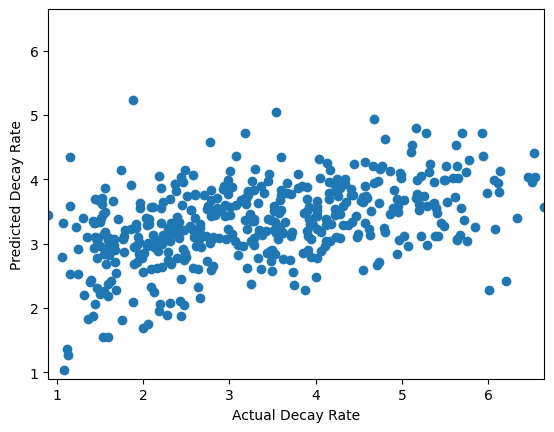

0.4568606678558512
0.4580278017112786


In [176]:
# use the trained model to predict decay rate for each transcript and then plot the predicted vs actual decay rate
import matplotlib.pyplot as plt
# Predict decay rate using the trained model
decay_data['Predicted Decay Rate'] = results.predict(X)
# Plot the predicted vs actual decay rate
plt.scatter(decay_data['Decay Rate'], decay_data['Predicted Decay Rate'])
plt.xlabel('Actual Decay Rate')
plt.ylabel('Predicted Decay Rate')
plt.xlim(min(decay_data['Decay Rate'].min(), decay_data['Predicted Decay Rate'].min()), max(decay_data['Decay Rate'].max(), decay_data['Predicted Decay Rate'].max()))
plt.ylim(min(decay_data['Decay Rate'].min(), decay_data['Predicted Decay Rate'].min()), max(decay_data['Decay Rate'].max(), decay_data['Predicted Decay Rate'].max()))
plt.show()
# %%
# print the correlation coefficient between the predicted and actual decay rate
print(decay_data['Decay Rate'].corr(decay_data['Predicted Decay Rate']))
print(decay_data['Decay Rate'].corr(decay_data['Predicted Decay Rate'], method='spearman'))

# # plot the residuals
# plt.scatter(decay_data['Predicted Decay Rate'], decay_data['Residuals'])
# plt.xlabel('Predicted Decay Rate')
# plt.ylabel('Residuals')
# plt.show()
# # %%
# # plot the residuals vs the actual decay rate
# plt.scatter(decay_data['Decay Rate'], decay_data['Residuals'])
# plt.xlabel('Actual Decay Rate')
# plt.ylabel('Residuals')
# plt.show()
# # %%

In [177]:
decay_data[['Decay Rate', 'Predicted Decay Rate']]

,Decay Rate,Predicted Decay Rate
FBtr0078968,4.856489,3.453238
FBtr0085874,5.414480,3.119956
FBtr0110823,3.850436,2.861141
FBtr0336467,6.003479,2.278342
FBtr0310660,4.243244,3.474024
...,...,...
FBtr0334848,4.219886,3.821041
FBtr0339673,3.935646,3.302798
FBtr0343419,2.554276,3.518023
FBtr0310541,4.159408,3.041002


In [178]:
print(full_data.loc[valD].drop("Decay Rate", axis=1).shape)
print(X.shape)

(99, 67)
(456, 68)


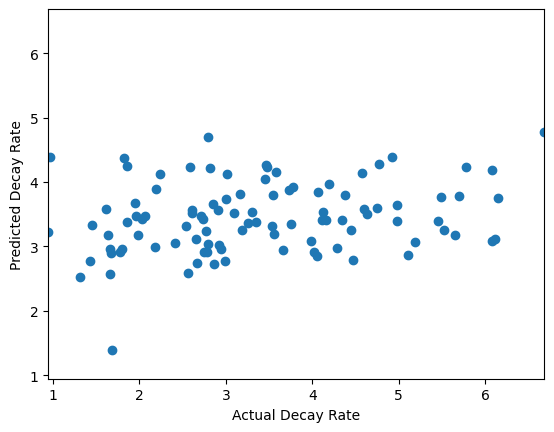

0.24367544403492472
0.23844848005209865


In [179]:
# use the trained model to predict decay rate for each transcript and then plot the predicted vs actual decay rate
import matplotlib.pyplot as plt
# Predict decay rate using the trained model
X_val = full_data.loc[valD].drop("Decay Rate", axis=1)
X_val = sm.add_constant(X_val)
valPred = results.predict(X_val)
valActual = full_data.loc[valD]['Decay Rate']
valPred = pd.Series(valPred, index=valD)
# Plot the predicted vs actual decay rate
plt.scatter(valActual, valPred)
plt.xlabel('Actual Decay Rate')
plt.ylabel('Predicted Decay Rate')
plt.xlim(min(valActual.min(), valPred.min()), max(valActual.max(), valPred.max()))
plt.ylim(min(valActual.min(), valPred.min()), max(valActual.max(), valPred.max()))
plt.show()
# %%
# print the correlation coefficient between the predicted and actual decay rate
print(valActual.corr(valPred))
print(valActual.corr(valPred, method='spearman'))

In [ ]:
from transformers import BertModel
m = BertModel.from_pretrained("Rostlab/prot_bert", output_hidden_states=True)
m.to("cuda")